# Fase 3 — Notebook 02: Análise Exploratória (EDA)

**Entrada:** `banco_de_dados/Base_ELSI_Bruta_Censo2022.csv` (produzido pelo Notebook 01).

**Objetivo:** caracterizar a base filtrada dos 70 municípios ELSI antes de qualquer
cálculo de IVS — descrever distribuições, detectar outliers, avaliar dados faltantes
e estudar a estrutura de correlação entre as 7 variáveis-componente do IVS. Esta EDA
alimenta a **Tabela 1** do artigo científico.

**Referência metodológica:**
- `docs/Cálculo IVS2012.docx` — regras operacionais do IVS-BH (denominador,
  `Dados_sig`, tratamento de sigilo).
- `docs/guia_analises.docx` — framework FIOCRUZ de EDA: medidas de tendência
  central (média / mediana / quantis), dispersão (DP / IQR / CV), gráficos
  (histograma, boxplot, matriz de correlação) e análise de missing.

**Decisão metodológica resolvida nesta etapa:**
Conforme `Cálculo IVS2012.docx`, seção *Tratamento dos dados*: "achamos melhor
considerar o número de responsáveis como número total de domicílios do setor".
Portanto o denominador adotado para os indicadores de saneamento é **V01042 (Total
de Responsáveis)**, não V00001. Isto resolve a inconsistência apontada no
`DIAGNOSTICO_COMPLETO_PROJETO.md` (Problema #3).

**Roteiro:**
1. Imports e carregamento.
2. Tipagem e tratamento de sigilo (`X` → `NaN`).
3. Classificação `Dados_sig` e filtro dos setores `OK`.
4. Cálculo das 7 proporções brutas (sem normalização).
5. Descritivas globais.
6. Descritivas por município.
7. Descritivas por região.
8. Distribuições — histogramas.
9. Distribuições — boxplots por região.
10. Análise de outliers (regra IQR).
11. Análise de dados faltantes.
12. Matriz de correlação (Pearson e Spearman).
13. Exportação dos artefatos.

## 1. Imports e carregamento da base filtrada

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)


def _find_project_root():
    """Detecta a raiz do projeto (independente de onde o Jupyter inicia o kernel)."""
    cwd = Path.cwd().resolve()
    for d in [cwd, *cwd.parents]:
        if (d / 'requirements.txt').is_file() and (d / 'dados').is_dir() and (d / 'docs').is_dir():
            return d
    raise RuntimeError(f'Raiz do projeto não encontrada a partir de: {cwd}')

ROOT = _find_project_root()
CAMINHO_BD  = str(ROOT / 'banco_de_dados') + os.sep
CAMINHO_EDA = str(ROOT / 'banco_de_dados' / 'eda') + os.sep
CAMINHO_FIG = str(ROOT / 'banco_de_dados' / 'eda' / 'figuras') + os.sep
os.makedirs(CAMINHO_EDA, exist_ok=True)
os.makedirs(CAMINHO_FIG, exist_ok=True)
print(f'Raiz do projeto: {ROOT}')

df = pd.read_csv(CAMINHO_BD + 'Base_ELSI_Bruta_Censo2022.csv', sep=';', dtype=str)
print(f'Base carregada: {len(df):,} setores × {len(df.columns)} colunas')
print(f'Municípios distintos: {df["CD_MUN"].nunique()}')
print(f'UFs distintas: {df["CD_UF"].nunique()}')

Raiz do projeto: D:\Iniciação Cientifica\Projeto_IVS_Censo22


Base carregada: 109,032 setores × 47 colunas
Municípios distintos: 70
UFs distintas: 22


## 2. Tipagem e tratamento de sigilo

O IBGE marca células sigilosas com `X`. Para a EDA, convertemos `X` em `NaN` (as
estatísticas descritivas pulam essas observações). A classificação `Dados_sig` da
próxima célula decide quais setores ficam fora da análise.

In [2]:
COLS_TEXTO = ['CD_SETOR', 'CD_UF', 'CD_MUN', 'NM_MUN', 'NM_BAIRRO',
              'SITUACAO', 'Moradia_Predominante']
cols_num = [c for c in df.columns if c not in COLS_TEXTO]

# Marca sigilo ('X') como NaN.
df[cols_num] = df[cols_num].replace({'X': None, 'x': None})

# Algumas colunas (notadamente V06004 — rendimento médio) usam vírgula como
# separador decimal ('2453,03' em vez de '2453.03'). Trocamos antes de
# converter para numérico, senão pd.to_numeric devolve NaN para a maioria.
df[cols_num] = df[cols_num].apply(
    lambda c: c.astype(str).str.replace(',', '.', regex=False)
)
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors='coerce')

print('Tipos após conversão:')
print(df[cols_num[:5]].dtypes.to_string())
print(f"\nTotal de células nulas (incluindo sigilo): {df[cols_num].isna().sum().sum():,}")
print(f"V06004 (renda média) — válidos: {df['V06004'].notna().sum():,}/{len(df):,}")

Tipos após conversão:
v0001       int64
V00001    float64
V00002    float64
V00005    float64
V00006    float64

Total de células nulas (incluindo sigilo): 325,169
V06004 (renda média) — válidos: 106,262/109,032


## 3. Classificação `Dados_sig` e filtro de setores elegíveis

Implementa as regras do `Cálculo IVS2012.docx`:
- **SIGILOSO** — alguma das variáveis-base (`v0001`, `V00001`, `V01042`) é sigilo (`NaN`).
- **COLETIVO** — 100% dos domicílios são coletivos: `dom_col = V01042 − V00001 − V00002`,
  `% coletivos = dom_col / V01042 × 100`.
- **ZERADO** — `v0001 = 0`.
- **OK** — caso contrário; participa das análises.

In [3]:
# Regra Dados_sig — atualizada após auditoria (R5).
#
# A versão anterior usava `V01042 − V00001 − V00002` como proxy de "domicílios
# coletivos extras". Como o IBGE não conta responsáveis em coletivos da mesma
# forma, essa fórmula tendia a 0 (clip) e a regra COLETIVO nunca disparava.
#
# Versão revisada:
#  • SIGILOSO — alguma das variáveis-base (v0001, V00001, V01042) é sigilo (NaN).
#  • COLETIVO — V00002 (domicílios coletivos) representa ≥ 100% do total de
#               responsáveis V01042. Equivalente a setor com população só em
#               domicílios coletivos (presídios, asilos, alojamentos).
#  • ZERADO   — v0001 = 0.
#  • OK       — caso contrário; participa das análises.

pct_coletivos = np.where(
    df['V01042'].fillna(0) > 0,
    df['V00002'].fillna(0) / df['V01042'].replace(0, np.nan) * 100,
    0,
)

cond_sig    = df[['v0001', 'V00001', 'V01042']].isna().any(axis=1)
cond_col    = pct_coletivos >= 100
cond_zerado = df['v0001'].fillna(-1) == 0

df['Dados_sig'] = np.select(
    [cond_sig, cond_col, cond_zerado],
    ['SIGILOSO', 'COLETIVO', 'ZERADO'],
    default='OK',
)

resumo = df['Dados_sig'].value_counts().rename('n_setores').to_frame()
resumo['pct'] = (resumo['n_setores'] / len(df) * 100).round(2)
print('Elegibilidade dos setores (70 municípios ELSI):')
print(resumo.to_string())

df_ok = df[df['Dados_sig'] == 'OK'].copy()
print(f'\nSetores OK para análise: {len(df_ok):,}')
print(f'Municípios representados: {df_ok["CD_MUN"].nunique()}')


Elegibilidade dos setores (70 municípios ELSI):
           n_setores    pct
Dados_sig                  
OK            106281  97.48
SIGILOSO        2751   2.52



Setores OK para análise: 106,281
Municípios representados: 70


## 4. Cálculo das 7 proporções brutas (sem normalização)

Para a EDA usamos as **proporções brutas** dos componentes do IVS — a normalização
min-max só faz sentido depois, na construção do índice. Todos os denominadores
seguem o `Cálculo IVS2012.docx`:

| Variável | Numerador | Denominador |
|---|---|---|
| `pct_agua_inad` | V00112 a V00118 | V01042 |
| `pct_esgoto_inad` | V00312 a V00316 | V01042 |
| `pct_lixo_inad` | V00398 a V00402 | V01042 |
| `razao_moradores` | V00005 + V00006 | V01042 |
| `pct_analfab` | V00901 | V00900 (pop. 15+) |
| `renda_media` | V06004 (direto) | — |
| `pct_raca_pretpardind` | V01318 + V01320 + V01321 | v0001 |

**Tratamento de sigilo (decisão para EDA):** se *todas* as variáveis-numerador de
um indicador estão sigilosas (`NaN`), o indicador vira `NaN` também — não zero.
Isto preserva a transparência sobre dados faltantes nas tabelas descritivas e nos
mapas de missing. Implementado via `sum(axis=1, min_count=1)`.

> Decisão diferente da Fase 2, que convertia sigilo residual para zero (apropriado
> para o cálculo final do índice, mas mascara dados faltantes durante a EDA).

In [4]:
def safe_div(num, den):
    return np.where((den > 0) & den.notna(), num / den, np.nan)

agua_cols   = ['V00112', 'V00113', 'V00114', 'V00115', 'V00116', 'V00117', 'V00118']
esgoto_cols = ['V00312', 'V00313', 'V00314', 'V00315', 'V00316']
lixo_cols   = ['V00398', 'V00399', 'V00400', 'V00401', 'V00402']
raca_cols   = ['V01318', 'V01320', 'V01321']

# min_count=1 → se TODAS as parcelas estiverem sigilosas (NaN), a soma vira NaN
# (em vez do default 0). Isto preserva o sigilo nas proporções.
df_ok['pct_agua_inad']        = safe_div(df_ok[agua_cols].sum(axis=1, min_count=1),   df_ok['V01042'])
df_ok['pct_esgoto_inad']      = safe_div(df_ok[esgoto_cols].sum(axis=1, min_count=1), df_ok['V01042'])
df_ok['pct_lixo_inad']        = safe_div(df_ok[lixo_cols].sum(axis=1, min_count=1),   df_ok['V01042'])
df_ok['razao_moradores']      = safe_div(df_ok[['V00005','V00006']].sum(axis=1, min_count=1), df_ok['V01042'])
df_ok['pct_analfab']          = safe_div(df_ok['V00901'], df_ok['V00900'])
df_ok['renda_media']          = df_ok['V06004']
df_ok['pct_raca_pretpardind'] = safe_div(df_ok[raca_cols].sum(axis=1, min_count=1), df_ok['v0001'])

INDICADORES = ['pct_agua_inad', 'pct_esgoto_inad', 'pct_lixo_inad',
               'razao_moradores', 'pct_analfab', 'renda_media',
               'pct_raca_pretpardind']

# ---- C1 — Diagnóstico de proporções fora de [0, 1] ANTES do clipping ----
print('Diagnóstico de proporções fora de [0, 1] (antes do clipping):')
diag = []
for c in [x for x in INDICADORES if x.startswith('pct_')]:
    n_acima = int((df_ok[c] > 1).sum())
    n_abaixo = int((df_ok[c] < 0).sum())
    maximo = df_ok[c].max()
    diag.append({'variavel': c, 'n_>1': n_acima, 'n_<0': n_abaixo, 'max_bruto': round(maximo, 4)})
diag_df = pd.DataFrame(diag)
print(diag_df.to_string(index=False))

# Salva o diagnóstico para auditoria — útil para o relatório de integridade.
diag_df.to_csv(CAMINHO_EDA + 'diagnostico_proporcoes_fora_intervalo.csv',
               sep=';', index=False, encoding='utf-8-sig')

# Clipping mantido (necessário para que a EDA produza distribuições válidas em
# [0,1]), mas agora com diagnóstico transparente acima.
for c in [x for x in INDICADORES if x.startswith('pct_')]:
    df_ok[c] = df_ok[c].clip(lower=0, upper=1)

# ---- R4 — inspeção de razao_moradores em extremos ----
extremos_razao = pd.concat([
    df_ok.nsmallest(5, 'razao_moradores')[['CD_SETOR','NM_MUN','NM_BAIRRO','V00001','V00002','V01042','razao_moradores']],
    df_ok.nlargest(5, 'razao_moradores')[['CD_SETOR','NM_MUN','NM_BAIRRO','V00001','V00002','V01042','razao_moradores']],
])
print('\n5 menores e 5 maiores razao_moradores (auditoria — possíveis denominadores incorretos):')
print(extremos_razao.to_string(index=False))
extremos_razao.to_csv(CAMINHO_EDA + 'extremos_razao_moradores.csv',
                       sep=';', index=False, encoding='utf-8-sig')

print('\nProporções calculadas. Resumo rápido:')
print(df_ok[INDICADORES].describe().round(4).to_string())


Diagnóstico de proporções fora de [0, 1] (antes do clipping):


            variavel  n_>1  n_<0  max_bruto
       pct_agua_inad     0     0     1.0000
     pct_esgoto_inad     0     0     1.0000
       pct_lixo_inad     0     0     1.0000
         pct_analfab    10     0     5.3333
pct_raca_pretpardind     0     0     1.0000

5 menores e 5 maiores razao_moradores (auditoria — possíveis denominadores incorretos):
       CD_SETOR         NM_MUN    NM_BAIRRO  V00001  V00002  V01042  razao_moradores
530010805060378       Brasília          NaN     5.0     0.0    48.0         0.166667
355030866000285      São Paulo          NaN    60.0     0.0   135.0         0.703704
355030846000737      São Paulo          NaN    14.0     0.0    44.0         0.954545
330455705250341 Rio de Janeiro      Ribeira     8.0     0.0     8.0         1.000000
355030890000760      São Paulo          NaN    53.0     0.0    53.0         1.018868
150580905000081         Portel          NaN   117.0     0.0   117.0         8.786325
150580905000034         Portel          NaN    64.0 

       pct_agua_inad  pct_esgoto_inad  pct_lixo_inad  razao_moradores  pct_analfab  renda_media  pct_raca_pretpardind
count    106281.0000      106280.0000    106281.0000      106281.0000   89527.0000  106262.0000           106279.0000
mean          0.0825           0.0922         0.1255           2.6960       0.0423    4141.3292                0.5302
std           0.2208           0.2305         0.2638           0.3993       0.0514    4123.8783                0.2294
min           0.0000           0.0000         0.0000           0.1667       0.0000     318.8800                0.0000
25%           0.0000           0.0000         0.0000           2.4805       0.0131    1735.3325                0.3562
50%           0.0000           0.0000         0.0000           2.7143       0.0286    2545.9750                0.5756
75%           0.0166           0.0233         0.0710           2.9295       0.0545    4755.1975                0.7075
max           1.0000           1.0000         1.0000    

## 4b. (Diagnóstico) Comparação das duas faixas de variáveis de esgoto

O Relatório Metodológico legado tinha uma inconsistência: a aba *De_Para* indicava
**V00312–V00316** e a aba *Mapa_de_Arquivos* indicava **V00249–V00253**. Sem o
dicionário oficial do IBGE no repositório, esta célula faz uma comparação
empírica entre as duas faixas para subsidiar a decisão metodológica.

A leitura esperada:
- Se uma das faixas é "domicílios particulares ocupados (todos)" e a outra é
  "domicílios particulares ocupados *permanentes*", a soma dos *permanentes*
  é sempre ≤ à dos *ocupados totais*.
- A faixa que melhor casa com **V01042 (Total de Responsáveis)** é aquela cuja
  soma fica perto de — mas não acima de — V01042.

In [5]:
# Carregar V00249–V00253 (faixa alternativa) — exigem leitura adicional do CSV
# bruto, pois o Notebook 01 só baixou V00312–V00316. Como já temos
# Base_ELSI_Bruta_Censo2022.csv (sem essas 5 variáveis), reabrimos o CSV de
# domicílio2 só para os CD_SETOR ELSI.
import pandas as pd
from pathlib import Path

CAMINHO_DADOS = str(ROOT / 'dados') + os.sep
setores_elsi = set(df['CD_SETOR'].astype(str))

cols_alt = ['setor', 'V00249', 'V00250', 'V00251', 'V00252', 'V00253']
pedacos = []
for enc in ('utf-8', 'latin1', 'cp1252'):
    try:
        reader = pd.read_csv(
            CAMINHO_DADOS + 'Agregados_por_setores_caracteristicas_domicilio2_BR_20250417.csv',
            sep=';', dtype=str, usecols=cols_alt,
            encoding=enc, chunksize=100_000, low_memory=False,
        )
        for chunk in reader:
            chunk = chunk.rename(columns={'setor': 'CD_SETOR'})
            chunk = chunk[chunk['CD_SETOR'].isin(setores_elsi)]
            if len(chunk):
                pedacos.append(chunk)
        break
    except UnicodeDecodeError:
        continue
df_esg_alt = pd.concat(pedacos, ignore_index=True)
df_esg_alt[['V00249','V00250','V00251','V00252','V00253']] = (
    df_esg_alt[['V00249','V00250','V00251','V00252','V00253']]
        .replace({'X': None, 'x': None})
        .apply(pd.to_numeric, errors='coerce')
)
df_esg_alt['soma_249_253'] = df_esg_alt[['V00249','V00250','V00251','V00252','V00253']].sum(axis=1, min_count=1)

# Aliar à base OK
df_cmp = df_ok[['CD_SETOR', 'V01042', 'V00001'] + esgoto_cols].copy()
df_cmp['soma_312_316'] = df_cmp[esgoto_cols].sum(axis=1, min_count=1)
df_cmp = df_cmp.merge(df_esg_alt[['CD_SETOR', 'soma_249_253']], on='CD_SETOR', how='left')

print('Comparação das duas faixas de esgoto (setores OK):')
print(pd.DataFrame({
    'soma_249_253 (somatório por setor)': df_cmp['soma_249_253'].describe(),
    'soma_312_316 (somatório por setor)': df_cmp['soma_312_316'].describe(),
    'V01042 (denominador)':              df_cmp['V01042'].describe(),
    'V00001 (denominador alternativo)':  df_cmp['V00001'].describe(),
}).round(2).to_string())

# Qual faixa "estoura" o denominador V01042 com mais frequência?
n_estoura_312 = int((df_cmp['soma_312_316'] > df_cmp['V01042']).sum())
n_estoura_249 = int((df_cmp['soma_249_253'] > df_cmp['V01042']).sum())
n_estoura_312_v1 = int((df_cmp['soma_312_316'] > df_cmp['V00001']).sum())
n_estoura_249_v1 = int((df_cmp['soma_249_253'] > df_cmp['V00001']).sum())
print(f'\nSetores em que a soma > V01042:')
print(f'  V00312–V00316: {n_estoura_312:,}  ({n_estoura_312/len(df_cmp)*100:.2f}%)')
print(f'  V00249–V00253: {n_estoura_249:,}  ({n_estoura_249/len(df_cmp)*100:.2f}%)')
print(f'\nSetores em que a soma > V00001:')
print(f'  V00312–V00316: {n_estoura_312_v1:,}  ({n_estoura_312_v1/len(df_cmp)*100:.2f}%)')
print(f'  V00249–V00253: {n_estoura_249_v1:,}  ({n_estoura_249_v1/len(df_cmp)*100:.2f}%)')

# Comparação direta: a faixa "permanentes" tem soma ≤ a faixa "ocupados totais"?
df_cmp['diff'] = df_cmp['soma_249_253'] - df_cmp['soma_312_316']
n_249_maior = int((df_cmp['diff'] > 0).sum())
n_312_maior = int((df_cmp['diff'] < 0).sum())
n_iguais    = int((df_cmp['diff'] == 0).sum())
print(f'\nRelação setor a setor (V00249-253 vs V00312-316):')
print(f'  V00249-253 > V00312-316: {n_249_maior:,}')
print(f'  V00312-316 > V00249-253: {n_312_maior:,}')
print(f'  iguais:                   {n_iguais:,}')

# Exporta para auditoria
df_cmp[['CD_SETOR', 'V01042', 'V00001', 'soma_312_316', 'soma_249_253', 'diff']].to_csv(
    CAMINHO_EDA + 'diagnostico_esgoto_312_vs_249.csv',
    sep=';', index=False, encoding='utf-8-sig',
)
print('\nArquivo salvo: banco_de_dados/eda/diagnostico_esgoto_312_vs_249.csv')
print('Decisão metodológica: documentar a faixa adotada após confirmar com a orientadora.')


Comparação das duas faixas de esgoto (setores OK):
       soma_249_253 (somatório por setor)  soma_312_316 (somatório por setor)  V01042 (denominador)  V00001 (denominador alternativo)
count                           106281.00                           106280.00             106281.00                         106281.00
mean                                27.91                               15.48                183.30                            183.08
std                                 57.50                               44.69                 86.03                             85.99
min                                  0.00                                0.00                  5.00                              5.00
25%                                  0.00                                0.00                126.00                            126.00
50%                                  3.00                                0.00                178.00                            178.00
75%        


Arquivo salvo: banco_de_dados/eda/diagnostico_esgoto_312_vs_249.csv
Decisão metodológica: documentar a faixa adotada após confirmar com a orientadora.


## 5. Descritivas globais das 7 variáveis

Tabela síntese seguindo o guia FIOCRUZ (Seções 3 e 4): n, média, DP, CV, mínimo,
quartis, máximo, IQR, assimetria e curtose. Para o artigo, o par **(mediana, IQR)**
é mais robusto que **(média, DP)** quando há assimetria/outliers — calculamos os
dois para escolher na hora da redação.

In [6]:
def descritiva(s):
    s = s.dropna()
    if len(s) == 0:
        return pd.Series({k: np.nan for k in
            ['n','media','dp','cv_pct','min','p25','mediana','p75','max','iq','assim','curt']})
    mean = s.mean()
    return pd.Series({
        'n': int(len(s)),
        'media':   mean,
        'dp':      s.std(),
        'cv_pct':  (s.std() / mean * 100) if mean != 0 else np.nan,
        'min':     s.min(),
        'p25':     s.quantile(0.25),
        'mediana': s.median(),
        'p75':     s.quantile(0.75),
        'max':     s.max(),
        'iq':      s.quantile(0.75) - s.quantile(0.25),
        'assim':   s.skew(),
        'curt':    s.kurtosis(),
    })

desc_global = pd.DataFrame({c: descritiva(df_ok[c]) for c in INDICADORES}).T
desc_global = desc_global.round(4)
print('Descritivas globais (setores OK dos 70 municípios ELSI):\n')
print(desc_global.to_string())

Descritivas globais (setores OK dos 70 municípios ELSI):

                             n      media         dp    cv_pct       min        p25    mediana        p75          max         iq   assim     curt
pct_agua_inad         106281.0     0.0825     0.2208  267.7695    0.0000     0.0000     0.0000     0.0166       1.0000     0.0166  3.0717   8.4724
pct_esgoto_inad       106280.0     0.0922     0.2305  249.9178    0.0000     0.0000     0.0000     0.0233       1.0000     0.0233  2.7666   6.5442
pct_lixo_inad         106281.0     0.1255     0.2638  210.1813    0.0000     0.0000     0.0000     0.0710       1.0000     0.0710  2.2367   3.6961
razao_moradores       106281.0     2.6960     0.3993   14.8101    0.1667     2.4805     2.7143     2.9295       8.7863     0.4490  0.0790   3.9145
pct_analfab            89527.0     0.0423     0.0514  121.2686    0.0000     0.0131     0.0286     0.0545       1.0000     0.0414  4.6929  44.1412
renda_media           106262.0  4141.3292  4123.8783   99.57

## 6. Descritivas por município

Tabela longa com, para cada município e variável: `n`, média, DP, mediana, P25, P75.
Útil para a **Tabela 1 do artigo** e para identificar municípios com perfis
discrepantes.

In [7]:
def desc_grupo(grupo, col):
    s = grupo[col].dropna()
    if len(s) == 0:
        return pd.Series({k: np.nan for k in ['n','media','dp','p25','mediana','p75']})
    return pd.Series({
        'n':       int(len(s)),
        'media':   s.mean(),
        'dp':      s.std(),
        'p25':     s.quantile(0.25),
        'mediana': s.median(),
        'p75':     s.quantile(0.75),
    })

linhas = []
for (cd_uf, cd_mun, nm_mun), g in df_ok.groupby(['CD_UF', 'CD_MUN', 'NM_MUN'], sort=True):
    for col in INDICADORES:
        d = desc_grupo(g, col)
        d['CD_UF'] = cd_uf
        d['CD_MUN'] = cd_mun
        d['NM_MUN'] = nm_mun
        d['variavel'] = col
        linhas.append(d)
desc_mun = pd.DataFrame(linhas)[['CD_UF','CD_MUN','NM_MUN','variavel','n','media','dp','p25','mediana','p75']]
desc_mun = desc_mun.sort_values(['CD_UF','NM_MUN','variavel']).reset_index(drop=True)
print(f'Linhas geradas: {len(desc_mun)} (70 municípios × {len(INDICADORES)} variáveis)')
print('\nPrimeiras 14 linhas (2 municípios × 7 variáveis):')
print(desc_mun.head(14).round(4).to_string(index=False))

Linhas geradas: 490 (70 municípios × 7 variáveis)

Primeiras 14 linhas (2 municípios × 7 variáveis):
CD_UF  CD_MUN  NM_MUN             variavel      n     media        dp       p25   mediana       p75
   13 1300300 Autazes        pct_agua_inad  184.0    0.8063    0.3056    0.7636    0.9642    1.0000
   13 1300300 Autazes          pct_analfab  160.0    0.1474    0.1125    0.0719    0.1193    0.1979
   13 1300300 Autazes      pct_esgoto_inad  184.0    0.8847    0.1919    0.8512    0.9728    1.0000
   13 1300300 Autazes        pct_lixo_inad  184.0    0.7203    0.4040    0.2176    0.9672    1.0000
   13 1300300 Autazes pct_raca_pretpardind  184.0    0.9094    0.0843    0.8464    0.9294    0.9862
   13 1300300 Autazes      razao_moradores  184.0    3.8803    0.7633    3.4000    3.7319    4.1898
   13 1300300 Autazes          renda_media  182.0 1355.9392 1250.9652  937.6875 1150.8850 1445.4750
   13 1302603  Manaus        pct_agua_inad 3199.0    0.2551    0.3073    0.0357    0.1188    0.3440

## 7. Descritivas por região geográfica

Agrega o resultado por região (Norte / Nordeste / Sudeste / Sul / Centro-Oeste)
usando a lista oficial ELSI como dicionário UF → região.

In [8]:
df_elsi = pd.read_csv(str(ROOT / 'dados' / 'municipios_elsi_brasil.csv'), sep=';', dtype=str)
mapa_regiao = dict(zip(df_elsi['uf_codigo'].str.zfill(2), df_elsi['regiao']))
df_ok['regiao'] = df_ok['CD_UF'].map(mapa_regiao)

linhas = []
for regiao, g in df_ok.groupby('regiao', sort=True):
    for col in INDICADORES:
        d = desc_grupo(g, col)
        d['regiao'] = regiao
        d['variavel'] = col
        linhas.append(d)
desc_reg = pd.DataFrame(linhas)[['regiao','variavel','n','media','dp','p25','mediana','p75']]
desc_reg = desc_reg.sort_values(['regiao','variavel']).reset_index(drop=True)
print(desc_reg.round(4).to_string(index=False))

      regiao             variavel       n     media        dp       p25   mediana       p75
Centro-Oeste        pct_agua_inad  9970.0    0.0918    0.2415    0.0000    0.0000    0.0305
Centro-Oeste          pct_analfab  8580.0    0.0357    0.0358    0.0132    0.0283    0.0485
Centro-Oeste      pct_esgoto_inad  9970.0    0.0939    0.2417    0.0000    0.0000    0.0131
Centro-Oeste        pct_lixo_inad  9970.0    0.1192    0.2676    0.0000    0.0000    0.0377
Centro-Oeste pct_raca_pretpardind  9970.0    0.5707    0.1567    0.4794    0.6072    0.6854
Centro-Oeste      razao_moradores  9970.0    2.7662    0.4112    2.5508    2.8058    3.0233
Centro-Oeste          renda_media  9969.0 4843.6842 4301.6704 2211.9000 3083.0500 5652.7900
    Nordeste        pct_agua_inad 20050.0    0.1271    0.2441    0.0000    0.0105    0.1173
    Nordeste          pct_analfab 18411.0    0.0764    0.0777    0.0259    0.0560    0.1019
    Nordeste      pct_esgoto_inad 20049.0    0.1755    0.3090    0.0000    0.000

## 8. Distribuições — histogramas

Histograma de cada uma das 7 variáveis (guia FIOCRUZ, Seção 5.5). Permite ver a
forma da distribuição: simétrica, assimétrica, bimodal, com massa em zero, etc.

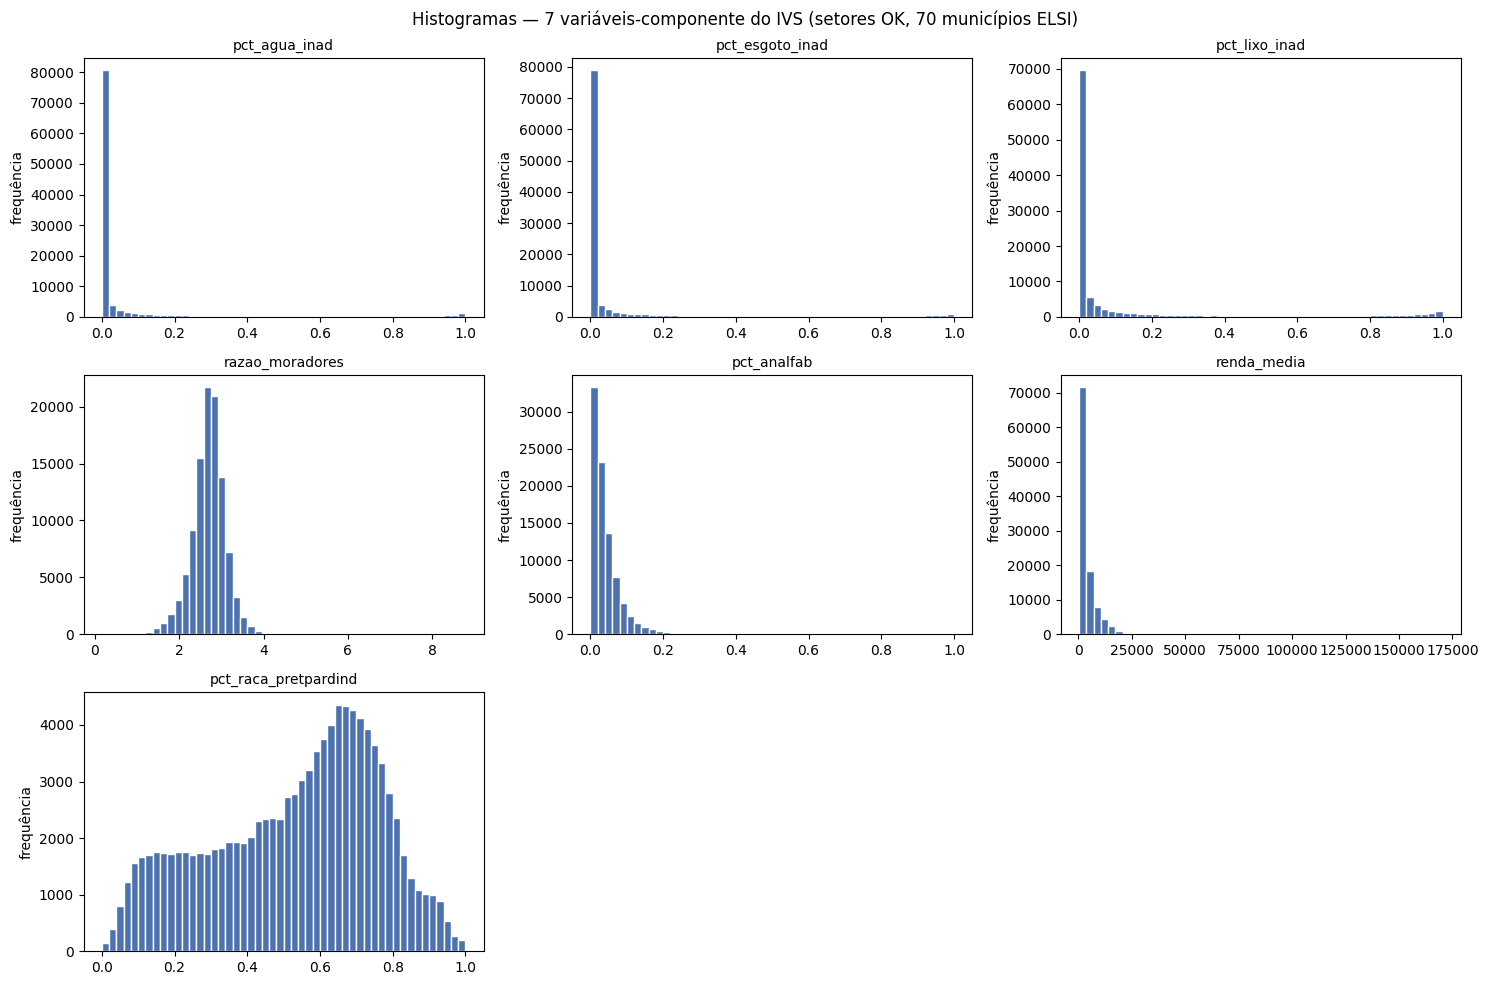

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(INDICADORES):
    ax = axes[i]
    df_ok[col].dropna().hist(bins=50, ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('frequência')
    ax.grid(False)
for j in range(len(INDICADORES), len(axes)):
    axes[j].axis('off')
fig.suptitle('Histogramas — 7 variáveis-componente do IVS (setores OK, 70 municípios ELSI)', fontsize=12)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Distribuições — boxplots por região

Boxplots estratificados por região (guia FIOCRUZ, Seção 5.3) para comparar centro,
dispersão e outliers entre regiões.

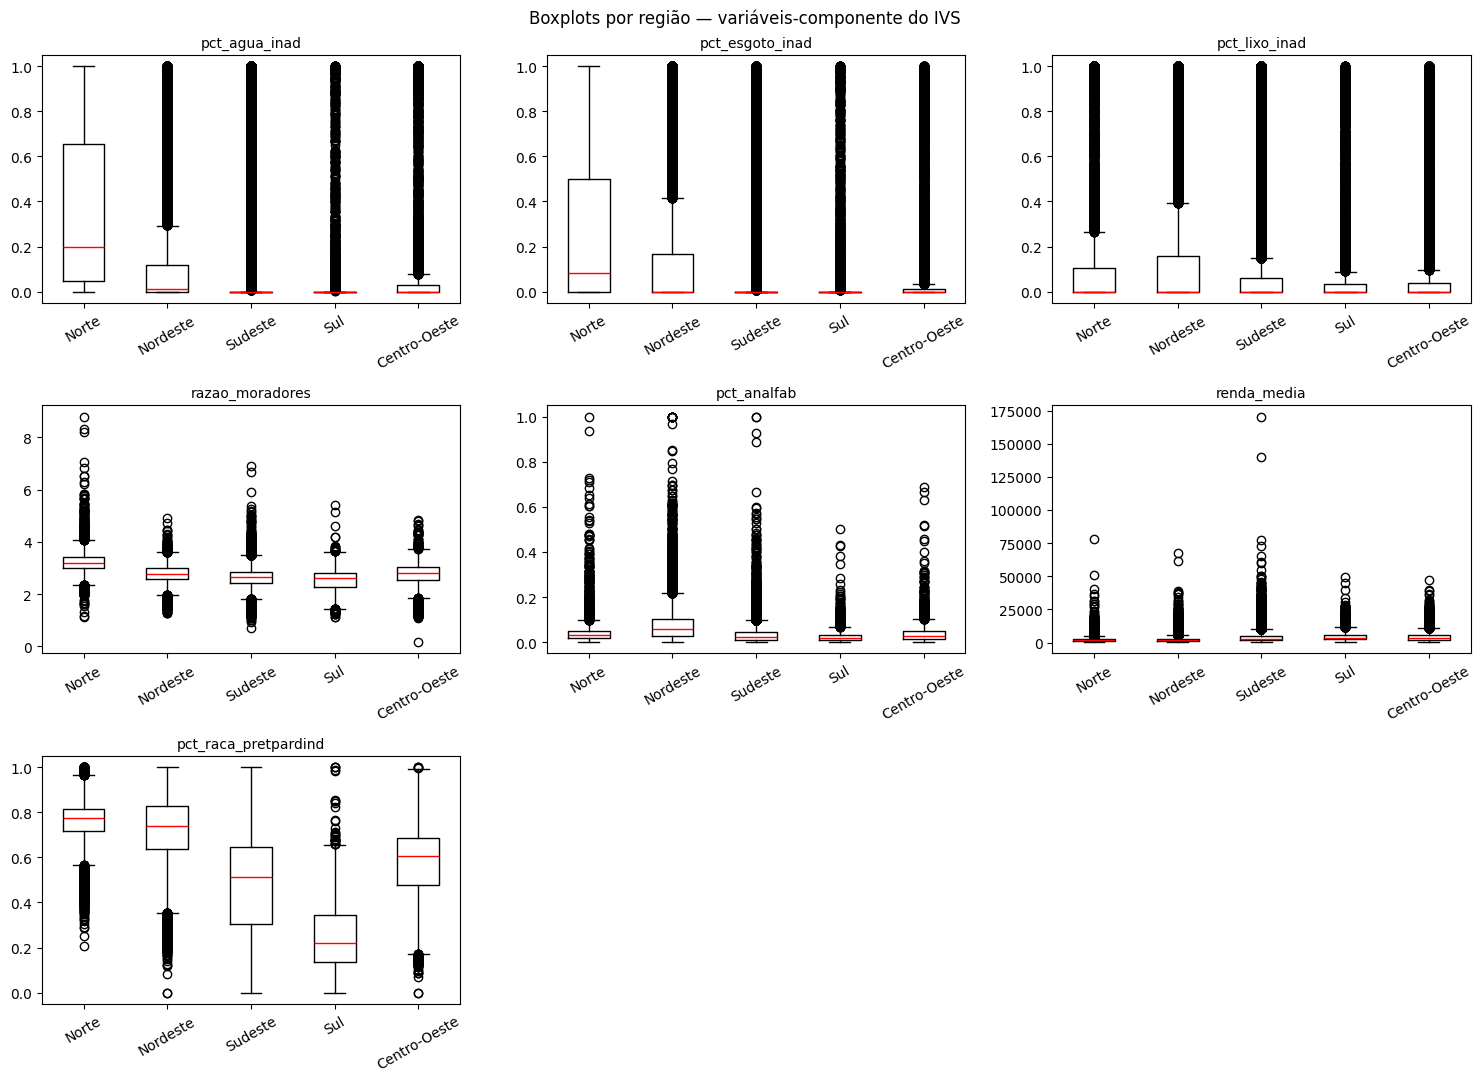

In [10]:
ordem_regiao = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()
for i, col in enumerate(INDICADORES):
    ax = axes[i]
    dados = [df_ok[df_ok['regiao'] == r][col].dropna() for r in ordem_regiao]
    ax.boxplot(dados, tick_labels=ordem_regiao, showfliers=True,
               medianprops={'color': 'red'})
    ax.set_title(col, fontsize=10)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(False)
for j in range(len(INDICADORES), len(axes)):
    axes[j].axis('off')
fig.suptitle('Boxplots por região — variáveis-componente do IVS', fontsize=12)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'boxplots_por_regiao.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Análise de outliers (regra do IQR)

Conta o número de setores fora do intervalo `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]` para cada
variável (guia FIOCRUZ, Seção 5.3). Outliers não devem ser removidos automaticamente
nesta fase — apenas inventariados.

In [11]:
def conta_outliers(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iq = q3 - q1
    lim_inf, lim_sup = q1 - 1.5*iq, q3 + 1.5*iq
    fora = ((s < lim_inf) | (s > lim_sup)).sum()
    p95 = s.quantile(0.95)
    n_p95 = int((s > p95).sum())
    # Flag: regra IQR é não-informativa quando P25 == mediana (distribuição
    # zero-inflada ou super-concentrada). Nestes casos, recomenda-se reportar
    # apenas o P95.
    iqr_inadequado = (q1 == s.median())
    return pd.Series({
        'n_validos':   int(len(s)),
        'q1': q1, 'q3': q3, 'iq': iq,
        'lim_inf': lim_inf, 'lim_sup': lim_sup,
        'n_outliers':  int(fora),
        'pct_outliers': round(fora / len(s) * 100, 2) if len(s) else np.nan,
        'p95': p95,
        'n_acima_p95':  n_p95,
        'pct_acima_p95': round(n_p95 / len(s) * 100, 2) if len(s) else np.nan,
        'iqr_nao_informativo': iqr_inadequado,
    })

outliers = pd.DataFrame({c: conta_outliers(df_ok[c]) for c in INDICADORES}).T
print('Outliers por variável — regra IQR (1.5 × IQR) + alternativa P95:\n')
print(outliers.round(4).to_string())
print('\nNota: `iqr_nao_informativo=True` indica distribuição zero-inflada;')
print('use n_acima_p95 / pct_acima_p95 em vez da regra IQR no relatório.')


Outliers por variável — regra IQR (1.5 × IQR) + alternativa P95:

                     n_validos         q1         q3        iq   lim_inf   lim_sup n_outliers pct_outliers        p95 n_acima_p95 pct_acima_p95 iqr_nao_informativo
pct_agua_inad           106281        0.0   0.016611  0.016611 -0.024917  0.041528      21502        20.23   0.722222        5309           5.0                True
pct_esgoto_inad         106280        0.0   0.023256  0.023256 -0.034884   0.05814      21145         19.9    0.77291        5314           5.0                True
pct_lixo_inad           106281        0.0   0.071038  0.071038 -0.106557  0.177596      19564        18.41   0.877451        5314           5.0                True
razao_moradores         106281   2.480519   2.929487  0.448968  1.807068  3.602939       3841         3.61    3.29703        5312           5.0               False
pct_analfab              89527   0.013083   0.054482  0.041399 -0.049015   0.11658       5344         5.97   0.125

## 11. Análise de dados faltantes

Mapa de calor da % de células faltantes em cada variável-componente, por município.
Indispensável para detectar municípios com cobertura ruim (guia FIOCRUZ, checklist
20.2).

Top 10 municípios com mais dados faltantes (média entre variáveis):
                     pct_agua_inad  pct_esgoto_inad  pct_lixo_inad  razao_moradores  pct_analfab  renda_media  pct_raca_pretpardind    _media
NM_MUN                                                                                                                                       
São Caetano do Sul             0.0              0.0            0.0              0.0        29.69         0.00                  0.00  4.241429
Porto Alegre                   0.0              0.0            0.0              0.0        27.46         0.00                  0.00  3.922857
Curitiba                       0.0              0.0            0.0              0.0        23.11         0.00                  0.00  3.301429
São Pedro da Aldeia            0.0              0.0            0.0              0.0        22.66         0.28                  0.00  3.277143
Belo Horizonte                 0.0              0.0            0.0              

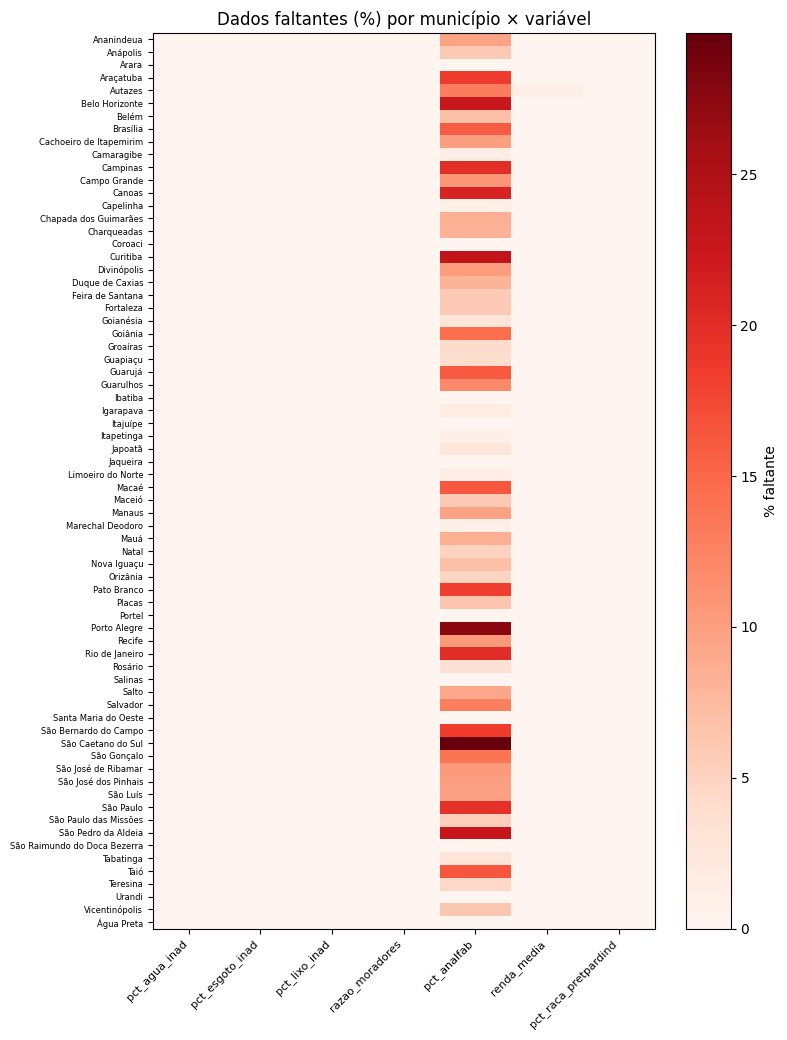

In [12]:
miss_mun = (df_ok.groupby('NM_MUN')[INDICADORES]
            .apply(lambda g: g.isna().mean() * 100)
            .round(2))
print('Top 10 municípios com mais dados faltantes (média entre variáveis):')
miss_mun['_media'] = miss_mun.mean(axis=1)
print(miss_mun.sort_values('_media', ascending=False).head(10).to_string())

fig, ax = plt.subplots(figsize=(8, max(8, len(miss_mun) * 0.15)))
m = miss_mun.drop(columns='_media').values
im = ax.imshow(m, aspect='auto', cmap='Reds', vmin=0, vmax=max(1, m.max()))
ax.set_yticks(range(len(miss_mun)))
ax.set_yticklabels(miss_mun.index, fontsize=6)
ax.set_xticks(range(len(INDICADORES)))
ax.set_xticklabels(INDICADORES, rotation=45, ha='right', fontsize=8)
fig.colorbar(im, ax=ax, label='% faltante')
ax.set_title('Dados faltantes (%) por município × variável')
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'missing_por_municipio.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Matriz de correlação

Correlação de Pearson (linear) e Spearman (postos / não paramétrica) entre as 7
variáveis (guia FIOCRUZ, Seção 11). Subsidia a futura análise fatorial — variáveis
muito correlacionadas tendem a se agrupar no mesmo fator.

Pearson:
                       pct_agua_inad  pct_esgoto_inad  pct_lixo_inad  razao_moradores  pct_analfab  renda_media  pct_raca_pretpardind
pct_agua_inad                 1.000            0.350          0.182            0.211        0.258       -0.120                 0.244
pct_esgoto_inad               0.350            1.000          0.206            0.285        0.426       -0.225                 0.320
pct_lixo_inad                 0.182            0.206          1.000           -0.002        0.234       -0.102                 0.204
razao_moradores               0.211            0.285         -0.002            1.000        0.285       -0.322                 0.475
pct_analfab                   0.258            0.426          0.234            0.285        1.000       -0.346                 0.441
renda_media                  -0.120           -0.225         -0.102           -0.322       -0.346        1.000                -0.680
pct_raca_pretpardind          0.244            0.320       

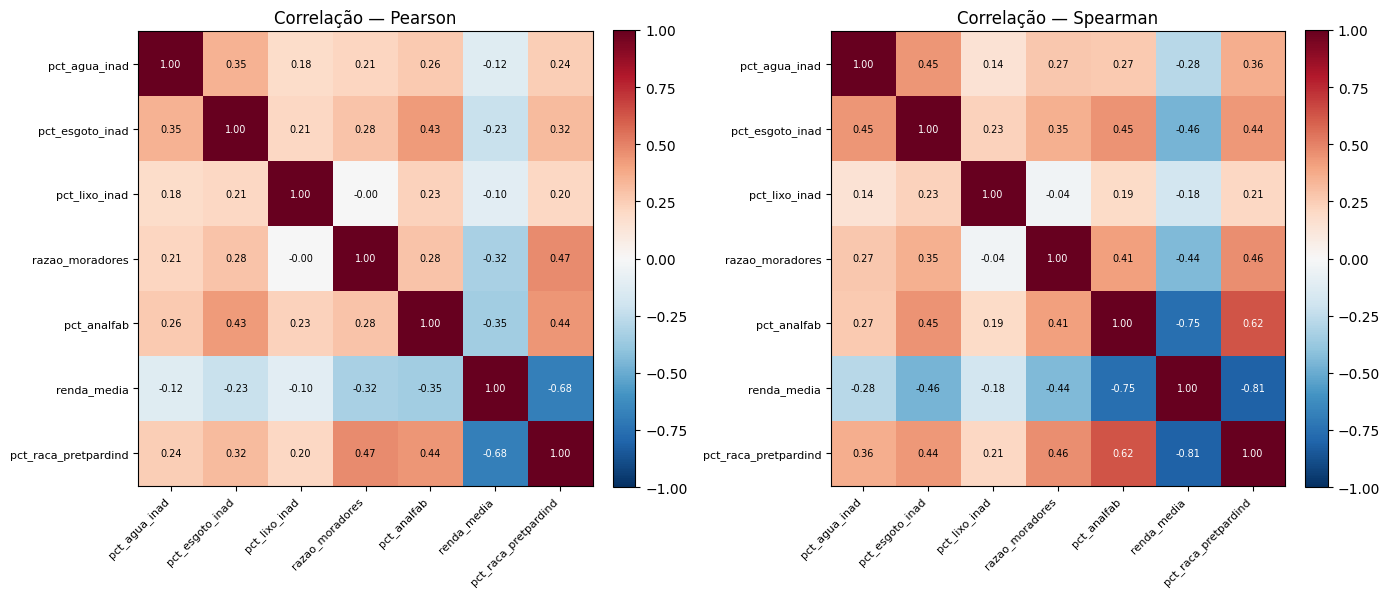

In [13]:
corr_p = df_ok[INDICADORES].corr(method='pearson').round(3)
corr_s = df_ok[INDICADORES].corr(method='spearman').round(3)

print('Pearson:\n', corr_p.to_string(), '\n')
print('Spearman:\n', corr_s.to_string())

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 6))
for ax, mat, titulo in [(a1, corr_p, 'Pearson'), (a2, corr_s, 'Spearman')]:
    im = ax.imshow(mat.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(INDICADORES))); ax.set_yticks(range(len(INDICADORES)))
    ax.set_xticklabels(INDICADORES, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(INDICADORES, fontsize=8)
    ax.set_title(f'Correlação — {titulo}')
    for i in range(len(INDICADORES)):
        for j in range(len(INDICADORES)):
            ax.text(j, i, f'{mat.values[i,j]:.2f}', ha='center', va='center',
                    color='black' if abs(mat.values[i,j]) < 0.6 else 'white', fontsize=7)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(CAMINHO_FIG + 'matriz_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 13. Exportação dos artefatos

Salva os CSVs com as tabelas descritivas em `banco_de_dados/eda/`. As figuras
já foram salvas em `banco_de_dados/eda/figuras/` ao longo das células anteriores.

In [14]:
desc_global.to_csv(CAMINHO_EDA + 'descritivas_globais.csv',       sep=';', encoding='utf-8-sig')
desc_mun.to_csv(   CAMINHO_EDA + 'descritivas_por_municipio.csv', sep=';', encoding='utf-8-sig', index=False)
desc_reg.to_csv(   CAMINHO_EDA + 'descritivas_por_regiao.csv',    sep=';', encoding='utf-8-sig', index=False)
outliers.to_csv(   CAMINHO_EDA + 'outliers.csv',                  sep=';', encoding='utf-8-sig')
miss_mun.drop(columns='_media').to_csv(CAMINHO_EDA + 'missing_por_municipio.csv',
                                        sep=';', encoding='utf-8-sig')
corr_p.to_csv(CAMINHO_EDA + 'correlacao_pearson.csv',  sep=';', encoding='utf-8-sig')
corr_s.to_csv(CAMINHO_EDA + 'correlacao_spearman.csv', sep=';', encoding='utf-8-sig')
resumo.to_csv(CAMINHO_EDA + 'elegibilidade_setores.csv', sep=';', encoding='utf-8-sig')

print('Artefatos exportados em', CAMINHO_EDA)
print('Figuras em', CAMINHO_FIG)

Artefatos exportados em D:\Iniciação Cientifica\Projeto_IVS_Censo22\banco_de_dados\eda\
Figuras em D:\Iniciação Cientifica\Projeto_IVS_Censo22\banco_de_dados\eda\figuras\
